# 탑승완료 출발지·목적지 이동 흐름 분석

탑승완료(승차·하차 기록이 모두 있고 취소되지 않은) 건을 기준으로,
같은 구에서 출발·도착한 이동과 서로 다른 구를 오간 이동을 나눠서
상위 이동 경로와 구별 순유입·순유출을 확인한다. 

In [14]:
import json
import platform
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

request_path = DATA_DIR / '서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv'
print(request_path)

df = pd.read_csv(request_path)
print(f'전체 행 수: {len(df):,}')
df.head()

/Users/blaumonde/calltaxi-DA/data/processed/서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv
전체 행 수: 1,722,490


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaN,용산구,남영동,강북구,수유제2동,기타,3400.0,17667,특장차,지체
1,2025-01-01 00:03:10.557,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaN,NaN,2025-01-01 00:21:15.000,영등포구,여의동,강서구,화곡제6동,기타,NaN,0,특장차,뇌병
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,2025-01-01 00:49:45.857,NaN,노원구,상계5동,노원구,하계1동,기타,1500.0,2910,특장차,뇌병
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaN,영등포구,당산제1동,중구,명동,기타,2900.0,10421,특장차,지체
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaN,송파구,오금동,서초구,내곡동,기타,3000.0,11943,특장차,지체


## 탑승완료 필터링

승차일시·하차일시가 모두 있고, 취소일시가 없는 건만 탑승완료로 간주한다.

In [15]:
completed = df[
    df['승차일시'].notna()
    & df['하차일시'].notna()
    & df['취소일시'].isna()
].copy()

print(f'탑승완료 건수: {len(completed):,} / 전체 {len(df):,} ({len(completed) / len(df) * 100:.1f}%)')

탑승완료 건수: 1,477,067 / 전체 1,722,490 (85.8%)


## 출발구와 목적구 결측치 확인

이동 흐름 분석은 `출발구 → 목적구` 조합을 기준으로 수행한다.  
따라서 탑승완료 데이터에서 `출발구` 또는 `목적구`가 비어 있는 행이 있는지 확인한다.  
결측치가 있으면 자치구 간 이동 흐름에 포함할 수 없으므로 별도 검토 또는 제외가 필요하다.

In [16]:
missing_origin_count = completed["출발구"].isna().sum()
missing_destination_count = completed["목적구"].isna().sum()

missing_od = completed[
    completed["출발구"].isna()
    | completed["목적구"].isna()
].copy()

print(f"탑승완료 전체 건수: {len(completed):,}")
print(f"출발구 결측치: {missing_origin_count:,}건")
print(f"목적구 결측치: {missing_destination_count:,}건")
print(f"출발구 또는 목적구 결측치: {len(missing_od):,}건")

display(
    missing_od[
        ["접수일시", "승차일시", "하차일시", "출발구", "출발동", "목적구", "목적동"]
    ].head(20)
)

탑승완료 전체 건수: 1,477,067
출발구 결측치: 0건
목적구 결측치: 0건
출발구 또는 목적구 결측치: 0건


,접수일시,승차일시,하차일시,출발구,출발동,목적구,목적동


## 같은 구 vs 다른 구 분리

`출발구`와 `목적구`가 같은지 여부로 나눈다.
경기·인천 등 서울 밖 지역이 섞여 있으므로, 지도/구간 비교가 필요한 분석에서는
서울 25개구로 한정한 데이터도 함께 만든다.

In [17]:
SEOUL_25 = [
    '강남구', '강동구', '강북구', '강서구', '관악구',
    '광진구', '구로구', '금천구', '노원구', '도봉구',
    '동대문구', '동작구', '마포구', '서대문구', '서초구',
    '성동구', '성북구', '송파구', '양천구', '영등포구',
    '용산구', '은평구', '종로구', '중구', '중랑구',
]

same_gu = completed[completed['출발구'] == completed['목적구']]
diff_gu = completed[completed['출발구'] != completed['목적구']]

print('=== 탑승완료 전체 기준 (서울 밖 지역 포함) ===')
print(f'같은 구(구 내 이동): {len(same_gu):,}건 ({len(same_gu) / len(completed) * 100:.1f}%)')
print(f'다른 구(구 간 이동): {len(diff_gu):,}건 ({len(diff_gu) / len(completed) * 100:.1f}%)')

seoul_completed = completed[
    completed['출발구'].isin(SEOUL_25) & completed['목적구'].isin(SEOUL_25)
]
same_gu_seoul = seoul_completed[seoul_completed['출발구'] == seoul_completed['목적구']]
diff_gu_seoul = seoul_completed[seoul_completed['출발구'] != seoul_completed['목적구']]

print()
print(f'=== 서울 25개구 내 이동만 (전체 탑승완료의 {len(seoul_completed) / len(completed) * 100:.1f}%) ===')
print(f'같은 구: {len(same_gu_seoul):,}건 ({len(same_gu_seoul) / len(seoul_completed) * 100:.1f}%)')
print(f'다른 구: {len(diff_gu_seoul):,}건 ({len(diff_gu_seoul) / len(seoul_completed) * 100:.1f}%)')

=== 탑승완료 전체 기준 (서울 밖 지역 포함) ===
같은 구(구 내 이동): 526,119건 (35.6%)
다른 구(구 간 이동): 950,948건 (64.4%)

=== 서울 25개구 내 이동만 (전체 탑승완료의 92.3%) ===
같은 구: 526,105건 (38.6%)
다른 구: 836,563건 (61.4%)


## 서울 내부·외부 이동 흐름 분리

탑승완료 데이터의 `출발구`와 `목적구`를 기준으로 이동 흐름을 네 가지 유형으로 분리한다.

- `서울→서울`: 출발구와 목적구가 모두 서울 25개 자치구인 이동
- `서울→서울 외`: 출발구는 서울이고 목적구는 서울 외 지역인 이동
- `서울 외→서울`: 출발구는 서울 외 지역이고 목적구는 서울인 이동
- `서울 외→서울 외`: 출발구와 목적구가 모두 서울 외 지역인 이동

이를 통해 서울 내부 이동뿐 아니라 서울 경계를 오가는 광역 이동 수요와 서울 외 지역 간 이동이 얼마나 포함되어 있는지 확인한다.

In [18]:
completed_od = completed.dropna(subset=["출발구", "목적구"]).copy()

completed_od["출발_서울여부"] = completed_od["출발구"].isin(SEOUL_25)
completed_od["목적_서울여부"] = completed_od["목적구"].isin(SEOUL_25)

completed_od["이동유형"] = pd.NA

completed_od.loc[
    completed_od["출발_서울여부"] & completed_od["목적_서울여부"],
    "이동유형",
] = "서울→서울"

completed_od.loc[
    completed_od["출발_서울여부"] & ~completed_od["목적_서울여부"],
    "이동유형",
] = "서울→서울 외"

completed_od.loc[
    ~completed_od["출발_서울여부"] & completed_od["목적_서울여부"],
    "이동유형",
] = "서울 외→서울"

completed_od.loc[
    ~completed_od["출발_서울여부"] & ~completed_od["목적_서울여부"],
    "이동유형",
] = "서울 외→서울 외"

od_type_summary = (
    completed_od["이동유형"]
    .value_counts()
    .reindex(["서울→서울", "서울→서울 외", "서울 외→서울", "서울 외→서울 외"])
    .reset_index()
)

od_type_summary.columns = ["이동유형", "건수"]
od_type_summary["비율(%)"] = od_type_summary["건수"] / len(completed_od) * 100

display(od_type_summary)

print(f"출발구/목적구 결측 제외 후 분석 건수: {len(completed_od):,}건")

,이동유형,건수,비율(%)
0,서울→서울,1362668,92.254989
1,서울→서울 외,107735,7.293847
2,서울 외→서울,6615,0.447847
3,서울 외→서울 외,49,0.003317


출발구/목적구 결측 제외 후 분석 건수: 1,477,067건


## 서울 외→서울 외 이동 제거

이동 흐름 분석의 목적은 서울 내부 이동과 서울 경계를 오가는 이동을 확인하는 것이다.  
`서울 외→서울 외` 이동은 출발구와 목적구가 모두 서울시 25개 자치구 밖에 있는 건으로, 서울 내부 또는 서울 연계 이동 흐름 분석 대상에서 제외한다.

In [19]:
before_rows = len(completed_od)

outside_to_outside_mask = completed_od["이동유형"].eq("서울 외→서울 외")

removed_outside_to_outside = completed_od[outside_to_outside_mask].copy()

display(
    removed_outside_to_outside[
        ["접수일시", "승차일시", "하차일시", "출발구", "목적구", "이동유형"]
    ].head(20)
)

completed_od = completed_od.loc[~outside_to_outside_mask].copy()

after_rows = len(completed_od)

print(f"삭제 전 행 수: {before_rows:,}")
print(f"삭제 후 행 수: {after_rows:,}")
print(f"삭제된 서울 외→서울 외 이동 건수: {before_rows - after_rows:,}")

,접수일시,승차일시,하차일시,출발구,목적구,이동유형
984,2025-01-01 15:03:21.000,2025-01-01 15:24:57.307,2025-01-01 16:20:09.213,과천시,의정부시,서울 외→서울 외
15695,2025-01-05 15:15:05.000,2025-01-05 16:02:29.240,2025-01-05 16:48:55.177,광명시,성남시분당구,서울 외→서울 외
38331,2025-01-10 01:41:49.000,2025-01-10 02:32:02.833,2025-01-10 02:43:04.073,의정부시,의정부시,서울 외→서울 외
47347,2025-01-12 15:04:28.000,2025-01-12 15:36:12.013,2025-01-12 16:38:35.740,광명시,성남시분당구,서울 외→서울 외
79368,2025-01-19 15:04:23.000,2025-01-19 15:49:52.647,2025-01-19 16:36:27.833,광명시,성남시분당구,서울 외→서울 외
118695,2025-01-30 12:36:14.000,2025-01-30 13:00:54.663,2025-01-30 14:11:43.050,과천시,의정부시,서울 외→서울 외
140179,2025-02-04 18:13:22.000,2025-02-04 19:37:35.467,2025-02-04 19:52:42.303,의정부시,의정부시,서울 외→서울 외
159272,2025-02-08 15:21:52.000,2025-02-08 16:38:04.510,2025-02-08 16:51:36.753,남양주시,남양주시,서울 외→서울 외
222113,2025-02-21 16:04:51.000,2025-02-21 18:41:33.553,2025-02-21 19:02:46.480,의정부시,의정부시,서울 외→서울 외
379055,2025-03-27 22:30:06.000,2025-03-27 23:41:49.300,2025-03-27 23:59:32.070,의정부시,의정부시,서울 외→서울 외


삭제 전 행 수: 1,477,067
삭제 후 행 수: 1,477,018
삭제된 서울 외→서울 외 이동 건수: 49


## 같은 구 내 이동 전체 확인

`출발구`와 `목적구`가 같은 구 내 이동을 자치구별로 집계한다.  
서울 25개 자치구 전체를 확인하여, 구 내 이동이 많은 지역과 적은 지역을 함께 비교한다.

,출발구,건수
0,노원구,83566
1,강서구,48447
2,강동구,46776
3,은평구,32986
4,중랑구,23550
5,서대문구,22965
6,마포구,21954
7,송파구,21221
8,관악구,21191
9,양천구,20979


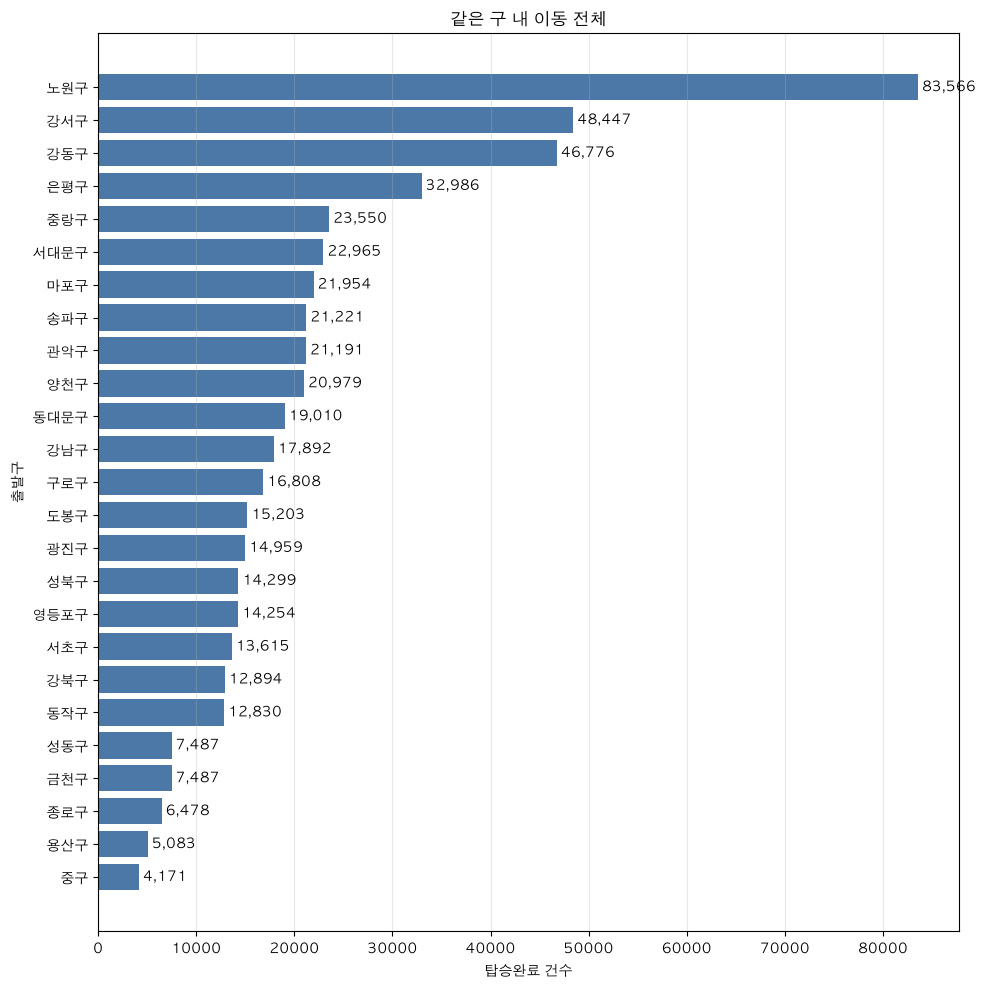

In [20]:
same_gu_rank = (
    same_gu_seoul
    .groupby("출발구")
    .size()
    .reset_index(name="건수")
    .sort_values("건수", ascending=False)
    .reset_index(drop=True)
)

display(same_gu_rank)

plot_data = same_gu_rank.sort_values("건수", ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))

ax.barh(plot_data["출발구"], plot_data["건수"], color="#4c78a8")
ax.set_title("같은 구 내 이동 전체")
ax.set_xlabel("탑승완료 건수")
ax.set_ylabel("출발구")
ax.grid(axis="x", alpha=0.3)

for index, value in enumerate(plot_data["건수"]):
    ax.text(value, index, f" {value:,.0f}", va="center")

plt.tight_layout()
plt.show()

## 다른 구 간 이동 전체 확인

`출발구`와 `목적구`가 서로 다른 서울 자치구 간 이동을 집계한다.  
전체 자치구 간 이동 조합을 확인하여, 특정 출발구와 목적구 사이에 이동이 집중되는 패턴을 살펴본다.

,출발구,목적구,건수,경로
0,서대문구,마포구,15727,서대문구 → 마포구
1,마포구,서대문구,15352,마포구 → 서대문구
2,노원구,도봉구,13932,노원구 → 도봉구
3,도봉구,노원구,13079,도봉구 → 노원구
4,마포구,은평구,12223,마포구 → 은평구
...,...,...,...,...
595,금천구,중랑구,48,금천구 → 중랑구
596,성북구,금천구,41,성북구 → 금천구
597,금천구,도봉구,40,금천구 → 도봉구
598,중랑구,금천구,35,중랑구 → 금천구


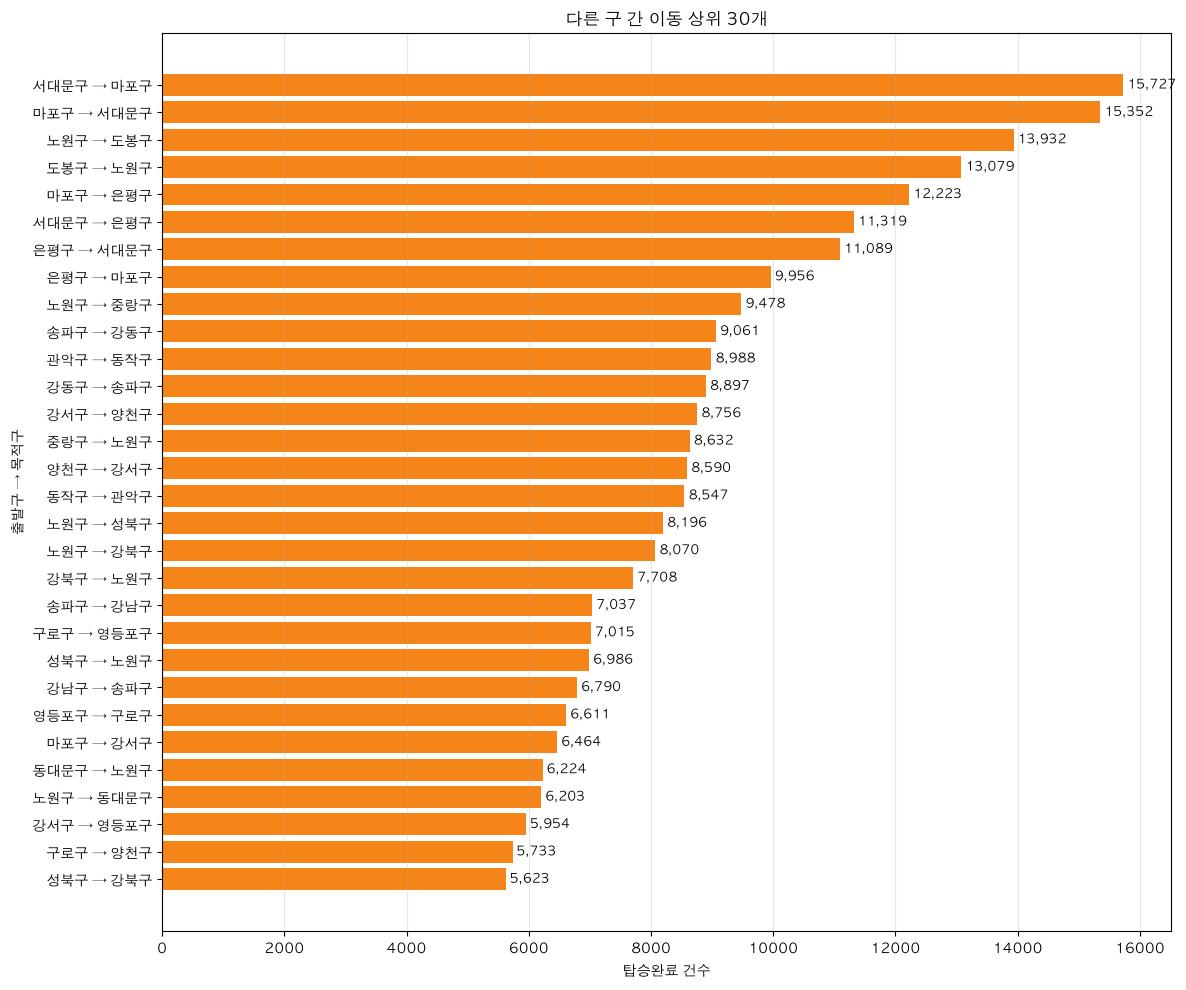

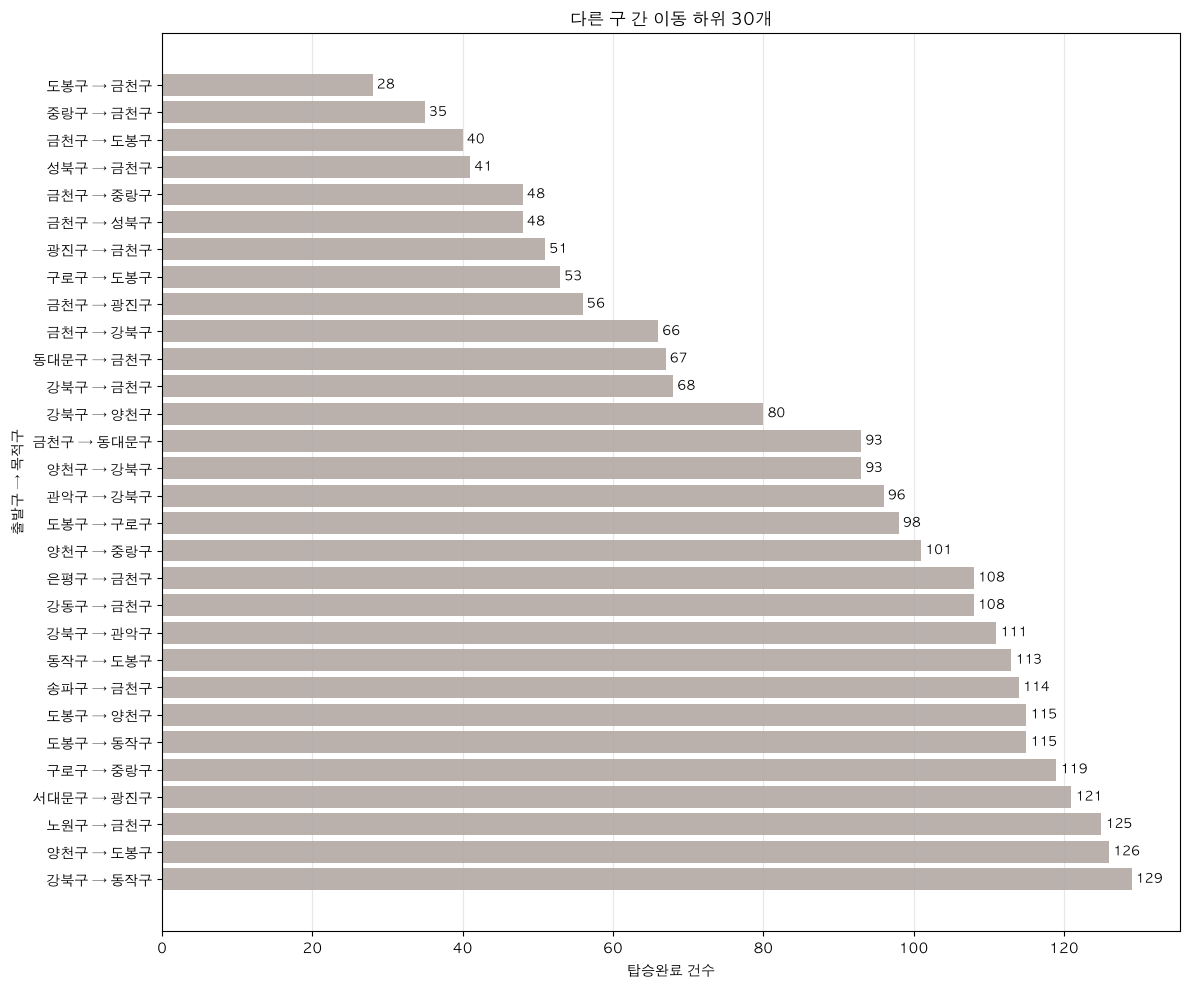

In [26]:
diff_gu_rank = (
    diff_gu_seoul
    .groupby(["출발구", "목적구"])
    .size()
    .reset_index(name="건수")
    .sort_values("건수", ascending=False)
    .reset_index(drop=True)
)

diff_gu_rank["경로"] = diff_gu_rank["출발구"] + " → " + diff_gu_rank["목적구"]

display(diff_gu_rank)

top_n = 30

top_route_plot = diff_gu_rank.head(top_n).copy()
top_route_plot = top_route_plot.sort_values("건수", ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))

ax.barh(top_route_plot["경로"], top_route_plot["건수"], color="#f58518")
ax.set_title(f"다른 구 간 이동 상위 {top_n}개")
ax.set_xlabel("탑승완료 건수")
ax.set_ylabel("출발구 → 목적구")
ax.grid(axis="x", alpha=0.3)

for index, value in enumerate(top_route_plot["건수"]):
    ax.text(value, index, f" {value:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

bottom_route_plot = diff_gu_rank.tail(top_n).copy()
bottom_route_plot = bottom_route_plot.sort_values("건수", ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))

ax.barh(bottom_route_plot["경로"], bottom_route_plot["건수"], color="#bab0ac")
ax.set_title(f"다른 구 간 이동 하위 {top_n}개")
ax.set_xlabel("탑승완료 건수")
ax.set_ylabel("출발구 → 목적구")
ax.grid(axis="x", alpha=0.3)

for index, value in enumerate(bottom_route_plot["건수"]):
    ax.text(value, index, f" {value:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

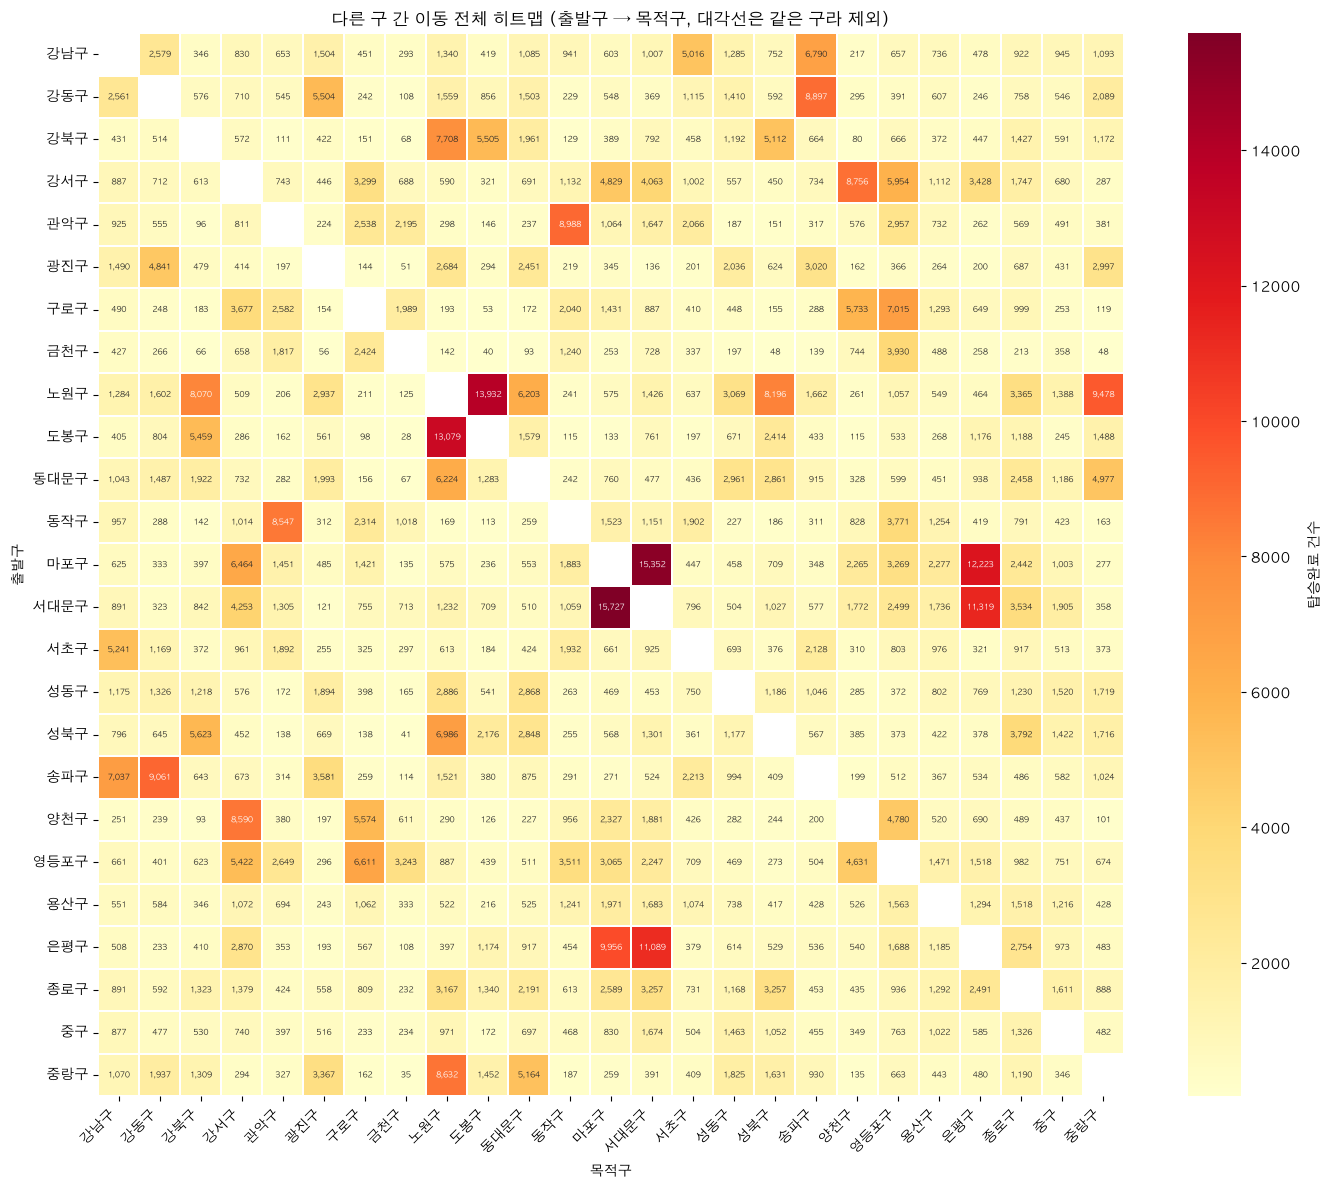

In [25]:
diff_gu_pivot = (
    diff_gu_rank
    .pivot(index="출발구", columns="목적구", values="건수")
    .reindex(index=SEOUL_25, columns=SEOUL_25, fill_value=0)
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    diff_gu_pivot,
    cmap="YlOrRd",
    linewidths=0.3,
    annot=True,
    fmt=",.0f",
    annot_kws={"fontsize": 6},
    cbar_kws={"label": "탑승완료 건수"},
)

plt.title("다른 구 간 이동 전체 히트맵 (출발구 → 목적구, 대각선은 같은 구라 제외)")
plt.xlabel("목적구")
plt.ylabel("출발구")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 자치구별 이동 순유입·순유출

다른 구 간 이동만 대상으로 자치구별 유입건수와 유출건수를 비교한다.  
`순유입건수`는 `유입건수 - 유출건수`로 계산하며, 값이 양수이면 해당 자치구가 도착지 역할을 더 많이 한다는 뜻이고, 음수이면 출발지 역할을 더 많이 한다는 뜻이다.

이 지표는 자치구별 이동 방향성을 확인하기 위한 보조 지표다. 유입은 목적지 역할이 강한 지역으로, 유출 지역은 다른 지역으로 차량이 빠져나가는 지역으로 해석할 수 있다. 다만 운영 문제 여부는 대기시간, 시간대별 수요, 차량 배치 현황과 함께 확인해야 한다.

In [28]:
out_by_gu = diff_gu_seoul.groupby("출발구").size()
in_by_gu = diff_gu_seoul.groupby("목적구").size()

net_flow = (
    in_by_gu
    .subtract(out_by_gu, fill_value=0)
    .reindex(SEOUL_25, fill_value=0)
)

net_flow_df = pd.DataFrame({
    "자치구": SEOUL_25,
    "유입건수": [in_by_gu.get(gu, 0) for gu in SEOUL_25],
    "유출건수": [out_by_gu.get(gu, 0) for gu in SEOUL_25],
})

net_flow_df["순유입건수"] = net_flow_df["유입건수"] - net_flow_df["유출건수"]

net_flow_df = net_flow_df.sort_values(
    "순유입건수",
    ascending=False,
).reset_index(drop=True)

display(net_flow_df)

,자치구,유입건수,유출건수,순유입건수
0,영등포구,46117,42548,3569
1,종로구,35784,32627,3157
2,중구,19816,16817,2999
3,은평구,41567,38910,2657
4,광진구,26488,24733,1755
5,강북구,31681,30934,747
6,동작구,28629,28082,547
7,성동구,24625,24083,542
8,강남구,31474,30942,532
9,용산구,20639,20245,394


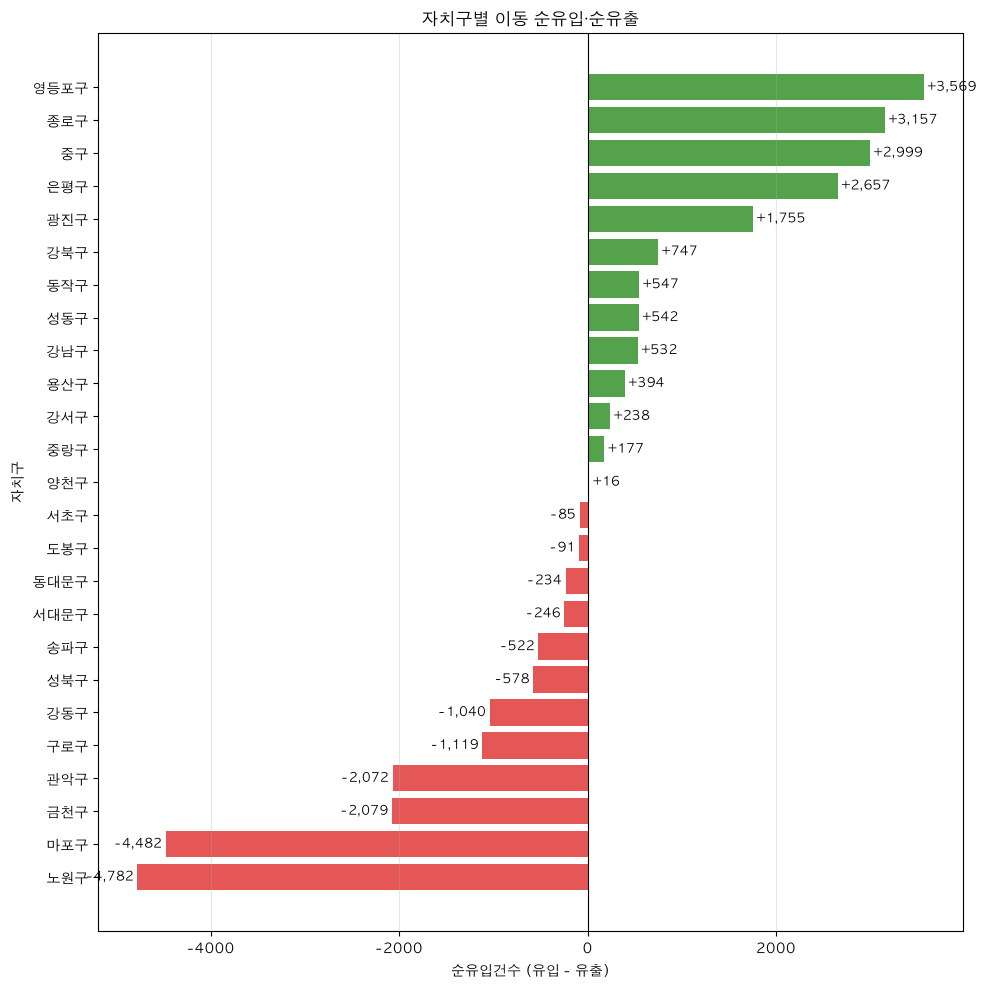

In [29]:
plot_data = net_flow_df.sort_values("순유입건수", ascending=True)

colors = [
    "#e45756" if value < 0 else "#54a24b"
    for value in plot_data["순유입건수"]
]

fig, ax = plt.subplots(figsize=(10, 10))

ax.barh(plot_data["자치구"], plot_data["순유입건수"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

ax.set_title("자치구별 이동 순유입·순유출")
ax.set_xlabel("순유입건수 (유입 - 유출)")
ax.set_ylabel("자치구")
ax.grid(axis="x", alpha=0.3)

for index, value in enumerate(plot_data["순유입건수"]):
    offset = 40 if value >= 0 else -40
    ha = "left" if value >= 0 else "right"
    ax.text(
        value + offset,
        index,
        f"{value:+,.0f}",
        va="center",
        ha=ha,
        fontsize=9,
    )

plt.tight_layout()
plt.show()

여기서 바로 “차량 부족”까지 말하긴 조금 이릅니다. 그건 대기시간, 시간대별 흐름, 차량 배치 현황이랑 같이 봐야